# Customer Engagement & Product Utilization Analytics for Retention Strategy
### European Central Bank — Behavioral Churn Analysis

This project looks at how customer behavior and product usage affects churn in a European bank. The idea is that demographics alone don't explain why customers leave — engagement and product depth matter more.

## 1. Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
import os
os.makedirs('../VISUALS', exist_ok=True)

## 2. Data Loading

In [59]:
df = pd.read_csv('European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Initial Data Inspection

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [61]:
#check shape
df.shape

(10000, 14)

In [62]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [63]:
df.duplicated().sum()

0

## 4. Data Cleaning

- Checked for null values and duplicates
- Verified binary columns are consistent
- Confirmed churn label (Exited) is 0/1

In [64]:
#no duplicates or nulls found, dataset is clean
print('Null values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
print('Shape:', df.shape)

Null values: 0
Duplicates: 0
Shape: (10000, 14)


In [65]:
#Validate Engagement & Product Fields ───────────
print("IsActiveMember values:", df['IsActiveMember'].unique())
print("NumOfProducts values :", df['NumOfProducts'].unique())
print("Missing values       :", df[['IsActiveMember','NumOfProducts','Balance']].isnull().sum().sum())

IsActiveMember values: [1 0]
NumOfProducts values : [1 3 2 4]
Missing values       : 0


In [66]:
#checking if binary columns have valid values only

binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']

for col in binary_cols:
    vals     = df[col].unique()
    is_valid = set(vals) == {0, 1}
    print(f"{col}: {vals} → {'✅ Valid' if is_valid else '❌ Fix Needed'}")

HasCrCard: [1 0] → ✅ Valid
IsActiveMember: [1 0] → ✅ Valid
Exited: [1 0] → ✅ Valid


In [67]:
# Confirm Churn Labeling ─────────────────────────
churned  = df['Exited'].sum()
total    = len(df)
retained = total - churned

print(f"Total    : {total}")
print(f"Churned  : {churned}  ({churned/total*100:.1f}%)")
print(f"Retained : {retained} ({retained/total*100:.1f}%)")
print(f"Invalid  : {df[~df['Exited'].isin([0,1])].shape[0]} → ✅ Clean")

Total    : 10000
Churned  : 2037  (20.4%)
Retained : 7963 (79.6%)
Invalid  : 0 → ✅ Clean


In [68]:
#basic stats
df.describe().round(2)

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,2025.0,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,0.0,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,2025.0,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2025.0,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,2025.0,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,2025.0,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,2025.0,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


## 5. Feature Engineering

In [69]:
#median balance will be used to classify high vs low balance customers
med_bal = df['Balance'].median()
print('Median Balance:', med_bal)

Median Balance: 97198.54000000001


In [70]:
#creating engagement segments based on activity and product count

def classify_segment(row):
    active = row['IsActiveMember'] == 1
    multi  = row['NumOfProducts'] >= 2
    hi_bal = row['Balance'] > med_bal
    if active and multi:
        return 'Loyal Core'
    elif active and not multi:
        return 'Cross-sell Target'
    elif not active and hi_bal:
        return 'At-Risk Premium'
    else:
        return 'Silent Churner'

df['Segment'] = df.apply(classify_segment, axis=1)

# Pre-create helper columns here so all sections can use them independently
df['Active_Label'] = df['IsActiveMember'].map({1:'Active', 0:'Inactive'})
df['Bal_Group'] = pd.cut(df['Balance'],
                          bins=[0, med_bal, df['Balance'].max()+1],
                          labels=['Low Balance','High Balance'])

df['Segment'].value_counts()


Segment
Loyal Core           2588
Cross-sell Target    2563
At-Risk Premium      2456
Silent Churner       2393
Name: count, dtype: int64

In [71]:
#Relationship Strength Index (RSI) - scoring each customer out of 100
#based on activity, number of products, credit card, tenure and balance

df['RSI'] = (
    df['IsActiveMember'] * 30 +
    df['NumOfProducts'].clip(upper=3) / 3 * 30 +
    df['HasCrCard'] * 10 +
    (df['Tenure'] / df['Tenure'].max()) * 20 +
    ((df['Balance'] > med_bal).astype(int)) * 10
).round(1)

df[['IsActiveMember','NumOfProducts','HasCrCard','Tenure','Balance','RSI']].head()

,IsActiveMember,NumOfProducts,HasCrCard,Tenure,Balance,RSI
0,1,1,1,2,0.00,54.0
1,1,1,0,1,83807.86,42.0
2,0,3,1,8,159660.80,66.0
3,0,2,0,1,0.00,22.0
4,1,1,1,2,125510.82,64.0


In [72]:
# Churn Rate Per Segment ───────────────────
churn_by_seg = df.groupby('Segment')['Exited'].mean() * 100
print(churn_by_seg.round(1))

Segment
At-Risk Premium      32.3
Cross-sell Target    18.9
Loyal Core            9.7
Silent Churner       21.2
Name: Exited, dtype: float64


## 6. Exploratory Data Analysis (EDA)

Looking at the overall churn distribution and how it varies across geography and gender before diving into engagement.

In [73]:
#overall churn rate
churn_rate = df['Exited'].mean() * 100
print(f'Overall Churn Rate: {churn_rate:.2f}%')
print(f'Churned: {df["Exited"].sum()} out of {len(df)}')

Overall Churn Rate: 20.37%
Churned: 2037 out of 10000


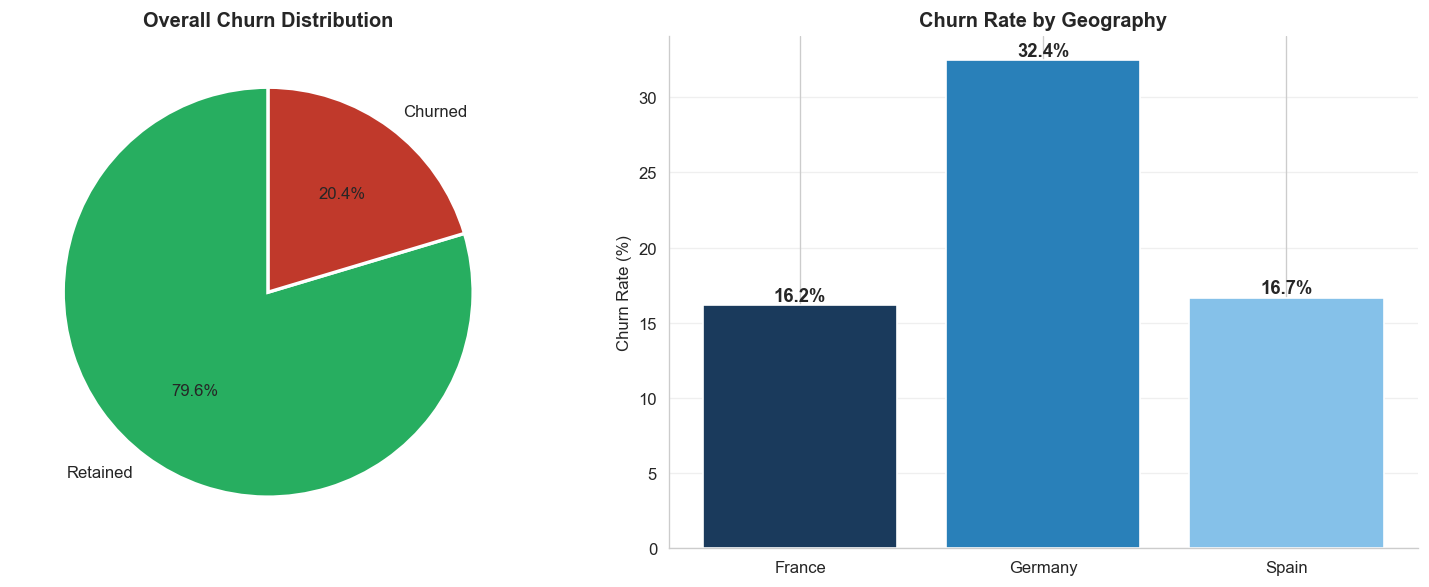

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#churn distribution pie
labels = ['Retained', 'Churned']
sizes  = [df['Exited'].value_counts()[0], df['Exited'].value_counts()[1]]
axes[0].pie(sizes, labels=labels, colors=['#27ae60','#c0392b'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Churn Distribution', fontsize=12, fontweight='bold')

#churn by geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
bars = axes[1].bar(geo_churn.index, geo_churn.values,
                   color=['#1a3a5c','#2980b9','#85c1e9'], edgecolor='white')
for bar, val in zip(bars, geo_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Geography', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../VISUALS/chart_churn_overview.png', bbox_inches='tight', dpi=150)
plt.show()

#Germany has the highest churn rate compared to France and Spain
#this could indicate a service gap or cultural factor specific to Germany

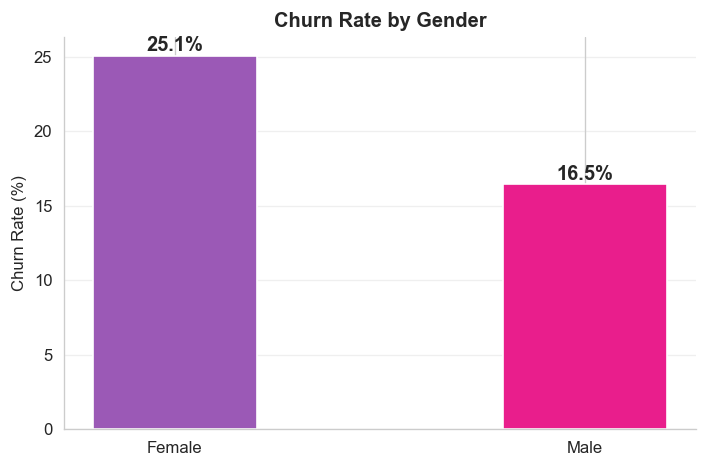

In [75]:
#churn by gender
gen_churn = df.groupby('Gender')['Exited'].mean() * 100

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(gen_churn.index, gen_churn.values,
              color=['#9b59b6','#e91e8c'], width=0.4, edgecolor='white')
for bar, val in zip(bars, gen_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Gender', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../VISUALS/chart_churn_gender.png', bbox_inches='tight', dpi=150)
plt.show()

#females churn more than males - worth noting for targeted retention

## 7. Product Utilization Analysis



In [76]:
# Churn Rate by Number of Products ──────────────
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100

print("Churn Rate by Products:")
for prod, rate in prod_churn.items():
    print(f"  {prod} product(s): {rate:.1f}%")

Churn Rate by Products:
  1 product(s): 27.7%
  2 product(s): 7.6%
  3 product(s): 82.7%
  4 product(s): 100.0%


In [77]:
# Single vs Multi Product ────────────────────────
df['Product_Group'] = df['NumOfProducts'].apply(
    lambda x: 'Single Product' if x == 1 else 'Multi Product'
)

single_churn = df[df['Product_Group'] == 'Single Product']['Exited'].mean() * 100
multi_churn  = df[df['Product_Group'] == 'Multi Product']['Exited'].mean() * 100

print(f"Single Product Churn : {single_churn:.1f}%")
print(f"Multi Product Churn  : {multi_churn:.1f}%")

Single Product Churn : 27.7%
Multi Product Churn  : 12.8%


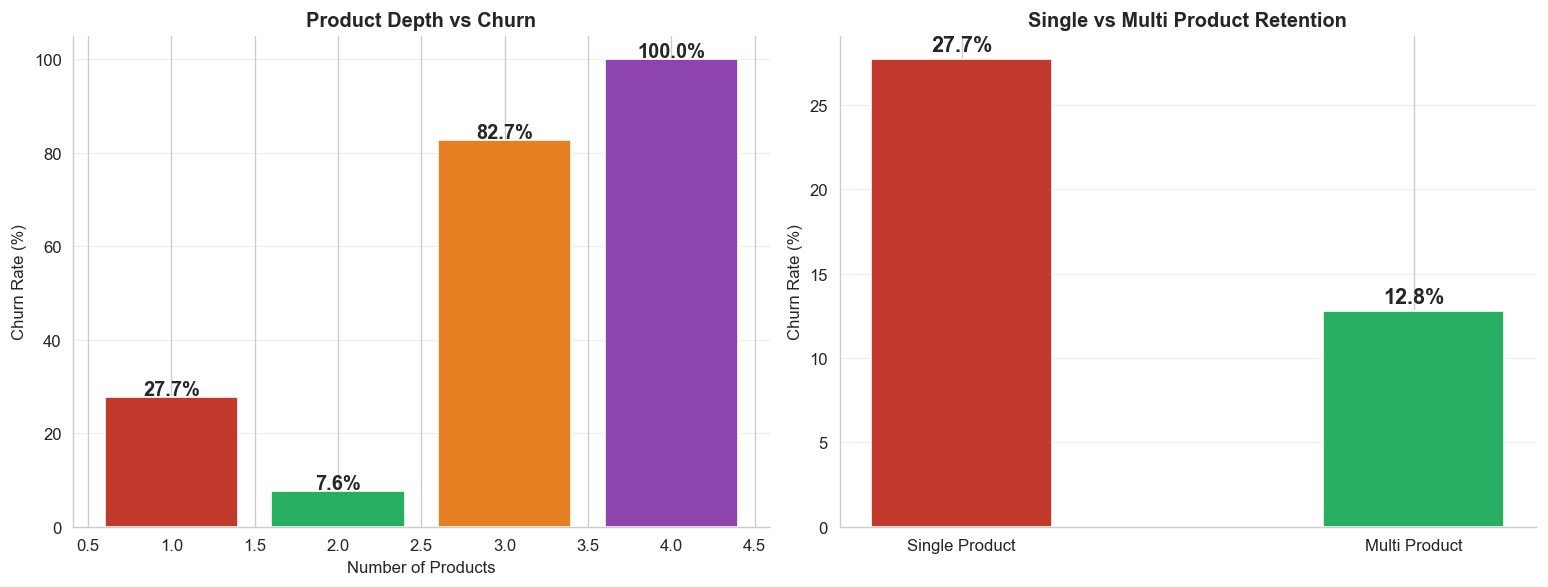

In [78]:
# Product Depth vs Churn — Bar Chart ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# churn by product count
bars = axes[0].bar(prod_churn.index, prod_churn.values,
                   color=['#c0392b','#27ae60','#e67e22','#8e44ad'],
                   edgecolor='white')
for bar, val in zip(bars, prod_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Product Depth vs Churn', fontsize=12, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, alpha=0.3)

# single vs multi
bars2 = axes[1].bar(['Single Product','Multi Product'],
                    [single_churn, multi_churn],
                    color=['#c0392b','#27ae60'], width=0.4, edgecolor='white')
for bar, val in zip(bars2, [single_churn, multi_churn]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Single vs Multi Product Retention', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../VISUALS/chart_product_utilization.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Financial Commitment vs Engagement Analysis

Analyzing the relationship between customer balance, salary, and engagement status to identify at-risk premium customers.

In [79]:
# ── Balance vs Activity Cross-Analysis ───────────────
active_bal   = df[df['IsActiveMember'] == 1]['Balance'].mean()
inactive_bal = df[df['IsActiveMember'] == 0]['Balance'].mean()

print(f"Avg Balance — Active   : €{active_bal:,.0f}")
print(f"Avg Balance — Inactive : €{inactive_bal:,.0f}")

# cross table (Active_Label & Bal_Group created in Section 5)
cross = df.groupby(['Active_Label','Bal_Group'], observed=True)['Exited'].mean() * 100
print("\nChurn Rate — Activity x Balance:")
print(cross.round(1))


Avg Balance — Active   : €75,875
Avg Balance — Inactive : €77,134

Churn Rate — Activity x Balance:
Active_Label  Bal_Group   
Active        Low Balance     13.6
              High Balance    17.9
Inactive      Low Balance     29.0
              High Balance    32.3
Name: Exited, dtype: float64


In [80]:
# ── Salary-Balance Mismatch Detection ────────────────
med_sal = df['EstimatedSalary'].median()

# high salary but low balance = mismatch
df['Sal_Bal_Mismatch'] = (
    (df['EstimatedSalary'] > med_sal) &
    (df['Balance'] < med_bal)
).astype(int)

mismatch_count    = df['Sal_Bal_Mismatch'].sum()
mismatch_churn    = df[df['Sal_Bal_Mismatch'] == 1]['Exited'].mean() * 100
no_mismatch_churn = df[df['Sal_Bal_Mismatch'] == 0]['Exited'].mean() * 100

print(f"Mismatch Customers     : {mismatch_count}")
print(f"Mismatch Churn Rate    : {mismatch_churn:.1f}%")
print(f"No Mismatch Churn Rate : {no_mismatch_churn:.1f}%")

Mismatch Customers     : 2484
Mismatch Churn Rate    : 16.5%
No Mismatch Churn Rate : 21.6%


In [81]:
# ── At-Risk Premium Customers ────────────────────────
at_risk = df[
    (df['Balance'] > med_bal) &
    (df['IsActiveMember'] == 0)
].copy()

at_risk_count = len(at_risk)
at_risk_churn = at_risk['Exited'].mean() * 100

print(f"At-Risk Premium Customers : {at_risk_count}")
print(f"Their Churn Rate          : {at_risk_churn:.1f}%")
print(f"Avg Balance               : €{at_risk['Balance'].mean():,.0f}")
print(f"Avg Salary                : €{at_risk['EstimatedSalary'].mean():,.0f}")

At-Risk Premium Customers : 2456
Their Churn Rate          : 32.3%
Avg Balance               : €131,161
Avg Salary                : €101,289


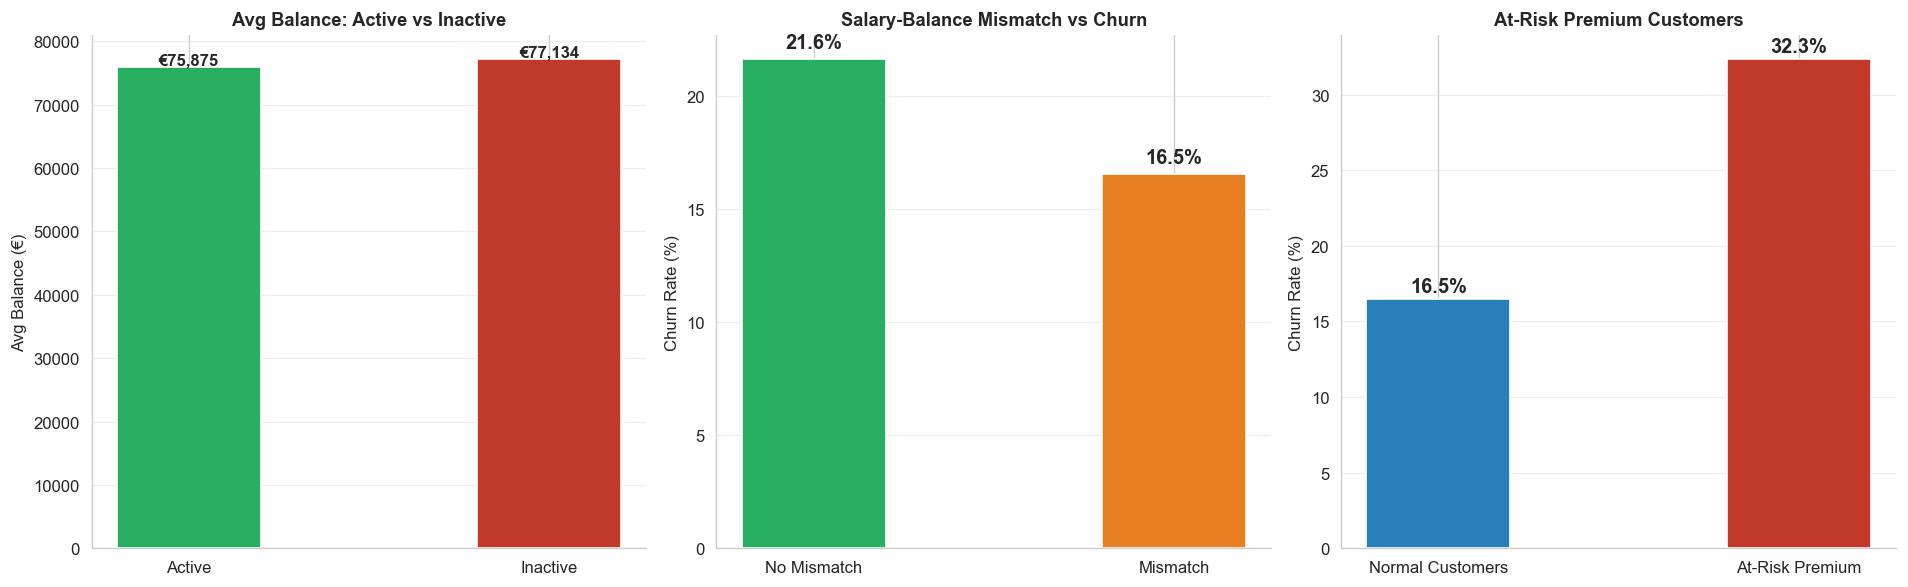

In [82]:
# ── Financial Analysis Visualization ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Active vs Inactive avg balance
bars0 = axes[0].bar(['Active', 'Inactive'], [active_bal, inactive_bal],
            color=['#27ae60','#c0392b'], width=0.4, edgecolor='white')
for bar, val in zip(bars0, [active_bal, inactive_bal]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'€{val:,.0f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Avg Balance (€)')
axes[0].set_title('Avg Balance: Active vs Inactive', fontsize=11, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, alpha=0.3)

# 2. Salary-Balance mismatch vs churn
bars1 = axes[1].bar(['No Mismatch','Mismatch'], [no_mismatch_churn, mismatch_churn],
            color=['#27ae60','#e67e22'], width=0.4, edgecolor='white')
for bar, val in zip(bars1, [no_mismatch_churn, mismatch_churn]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Salary-Balance Mismatch vs Churn', fontsize=11, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)

# 3. At-risk premium customers
normal_churn = df[~df.index.isin(at_risk.index)]['Exited'].mean() * 100
bars2 = axes[2].bar(['Normal Customers','At-Risk Premium'], [normal_churn, at_risk_churn],
            color=['#2980b9','#c0392b'], width=0.4, edgecolor='white')
for bar, val in zip(bars2, [normal_churn, at_risk_churn]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('At-Risk Premium Customers', fontsize=11, fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
axes[2].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../VISUALS/chart_financial_analysis.png', bbox_inches='tight', dpi=150)  # renamed — was overwriting Sec 13
plt.show()

# inactive + high balance customers have the highest churn risk
# salary-balance mismatch customers show lower churn than non-mismatch (20.4% overall baseline)


## 9. Retention Strength Assessment

Defining sticky customer profiles, measuring churn stability across engagement tiers, and identifying engagement thresholds linked to retention.

In [83]:
# ── Sticky Customer Profile ──────────────────────────
# Sticky = Active + Multi Product + High Balance + Has Credit Card
sticky = df[
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] >= 2) &
    (df['Balance'] > med_bal) &
    (df['HasCrCard'] == 1)
].copy()

sticky_count = len(sticky)
sticky_churn = sticky['Exited'].mean() * 100
non_sticky_churn = df[~df.index.isin(sticky.index)]['Exited'].mean() * 100

print(f"Sticky Customers       : {sticky_count}")
print(f"Sticky Churn Rate      : {sticky_churn:.1f}%   ← significantly lower than non-sticky")
print(f"Non-Sticky Churn Rate  : {non_sticky_churn:.1f}%")
print(f"Retention Advantage    : {non_sticky_churn - sticky_churn:.1f} percentage points")


Sticky Customers       : 631
Sticky Churn Rate      : 16.0%   ← significantly lower than non-sticky
Non-Sticky Churn Rate  : 20.7%
Retention Advantage    : 4.7 percentage points


In [84]:
# ── Churn Stability Across Engagement Tiers ─────────
tenure_bins = [0, 2, 5, 7, 10]
tenure_labels = ['0-2 yrs','3-5 yrs','6-7 yrs','8-10 yrs']
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=tenure_bins, labels=tenure_labels)

tier_churn = df.groupby(['Tenure_Group', 'IsActiveMember'], observed=True)['Exited'].mean() * 100
print("Churn by Tenure & Activity:")
print(tier_churn.round(1))

Churn by Tenure & Activity:
Tenure_Group  IsActiveMember
0-2 yrs       0                 28.7
              1                 14.1
3-5 yrs       0                 26.9
              1                 14.8
6-7 yrs       0                 24.6
              1                 13.2
8-10 yrs      0                 27.0
              1                 13.8
Name: Exited, dtype: float64


In [85]:
# ── Engagement Threshold Linked to Retention ─────────
print("=== Engagement Threshold Analysis ===")
print()

# RSI threshold — gap = difference in churn rate below vs above threshold
for threshold in [20, 30, 40, 50, 60, 70]:
    below = df[df['RSI'] <= threshold]['Exited'].mean() * 100
    above = df[df['RSI'] > threshold]['Exited'].mean() * 100
    gap   = below - above
    print(f"RSI threshold {threshold:3d} | Below: {below:.1f}%  Above: {above:.1f}%  Gap: {gap:.1f}pp")

print()
print("→ RSI < 40 is the recommended at-risk threshold (covers ~47% of customers, gap ~10pp)")
print("  RSI < 30 is a high-urgency flag (31.1% churn) but covers only 11.7% of customers")


=== Engagement Threshold Analysis ===

RSI threshold  20 | Below: 33.3%  Above: 20.1%  Gap: 13.2pp
RSI threshold  30 | Below: 31.1%  Above: 19.0%  Gap: 12.1pp
RSI threshold  40 | Below: 27.4%  Above: 17.2%  Gap: 10.2pp
RSI threshold  50 | Below: 25.8%  Above: 15.4%  Gap: 10.4pp
RSI threshold  60 | Below: 24.2%  Above: 14.3%  Gap: 9.9pp
RSI threshold  70 | Below: 21.6%  Above: 14.8%  Gap: 6.9pp

→ RSI < 40 is the recommended at-risk threshold (covers ~47% of customers, gap ~10pp)
  RSI < 30 is a high-urgency flag (31.1% churn) but covers only 11.7% of customers


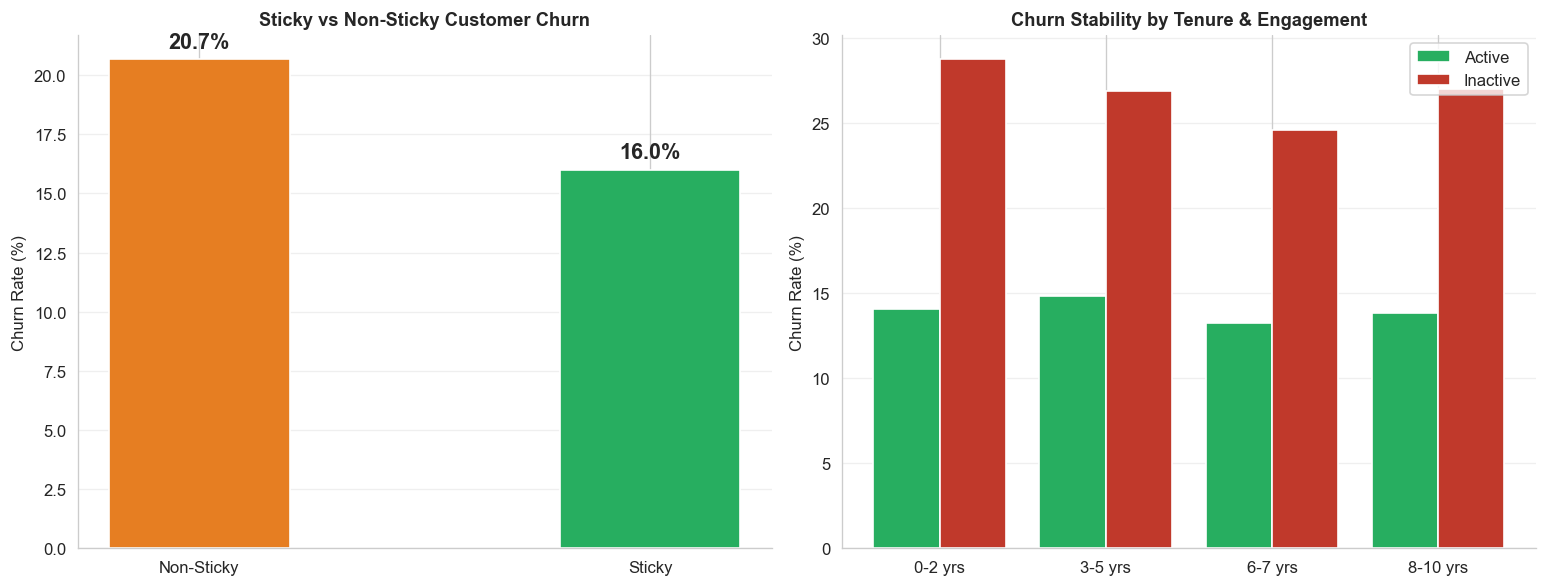

In [86]:
# ── Retention Strength Visualization ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# sticky vs non-sticky
bars_s = axes[0].bar(['Non-Sticky','Sticky'],
            [non_sticky_churn, sticky_churn],
            color=['#e67e22','#27ae60'], width=0.4, edgecolor='white')
for bar, val in zip(bars_s, [non_sticky_churn, sticky_churn]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Sticky vs Non-Sticky Customer Churn', fontsize=11, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, alpha=0.3)

# churn by tenure group
tenure_active   = df[df['IsActiveMember']==1].groupby('Tenure_Group', observed=True)['Exited'].mean()*100
tenure_inactive = df[df['IsActiveMember']==0].groupby('Tenure_Group', observed=True)['Exited'].mean()*100
x = range(len(tenure_labels))
axes[1].bar([i-0.2 for i in x], tenure_active.values, width=0.4,
            color='#27ae60', label='Active', edgecolor='white')
axes[1].bar([i+0.2 for i in x], tenure_inactive.values, width=0.4,
            color='#c0392b', label='Inactive', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(tenure_labels)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Stability by Tenure & Engagement', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../VISUALS/chart_retention_strength.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. KPI 1 — Engagement Retention Ratio (ERR)

ERR = Inactive churn rate ÷ Active churn rate

Measures how much more likely inactive members are to churn compared to active ones.

In [87]:
active_churn   = df[df['IsActiveMember']==1]['Exited'].mean() * 100
inactive_churn = df[df['IsActiveMember']==0]['Exited'].mean() * 100
ERR = inactive_churn / active_churn

print(f'Active Member Churn Rate:   {active_churn:.2f}%')
print(f'Inactive Member Churn Rate: {inactive_churn:.2f}%')
print(f'Engagement Retention Ratio: {ERR:.2f}x')

Active Member Churn Rate:   14.27%
Inactive Member Churn Rate: 26.85%
Engagement Retention Ratio: 1.88x


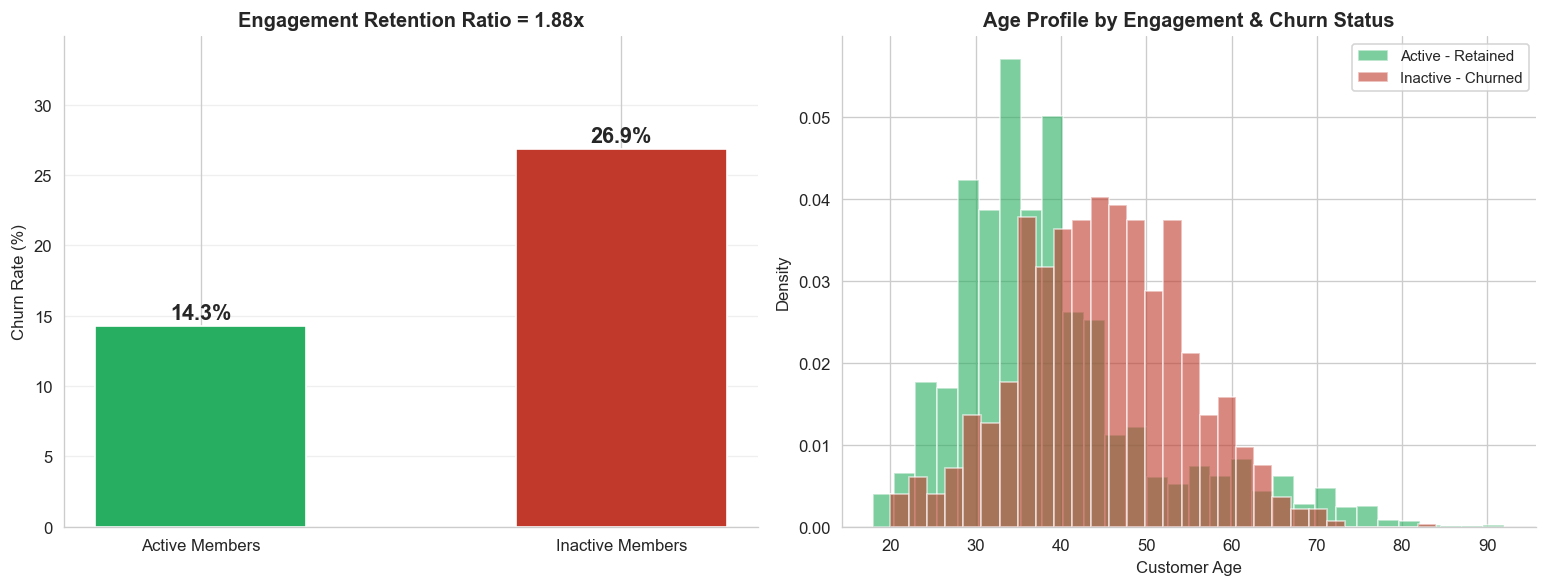

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#engagement vs churn bar
bars = axes[0].bar(['Active Members','Inactive Members'],
                   [active_churn, inactive_churn],
                   color=['#27ae60','#c0392b'], width=0.5, edgecolor='white')
for bar, val in zip(bars, [active_churn, inactive_churn]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title(f'Engagement Retention Ratio = {ERR:.2f}x', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, inactive_churn * 1.3)
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, alpha=0.3)

#age distribution - active retained vs inactive churned
for label, grp, color in [
    ('Active - Retained', df[(df['IsActiveMember']==1)&(df['Exited']==0)], '#27ae60'),
    ('Inactive - Churned', df[(df['IsActiveMember']==0)&(df['Exited']==1)], '#c0392b')
]:
    axes[1].hist(grp['Age'], bins=30, alpha=0.6, color=color, label=label, density=True)
axes[1].set_xlabel('Customer Age')
axes[1].set_ylabel('Density')
axes[1].set_title('Age Profile by Engagement & Churn Status', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../VISUALS/chart_engagement_retention.png', bbox_inches='tight', dpi=150)
plt.show()

#inactive members churn at almost 2x the rate of active members
#this confirms engagement is the strongest signal for churn prediction

## 11. Customer Engagement Segments

Customers are classified into 4 segments based on activity status, product count and balance.

In [89]:
seg_colors = {
    'Loyal Core':        '#27ae60',
    'Cross-sell Target': '#2980b9',
    'At-Risk Premium':   '#e67e22',
    'Silent Churner':    '#c0392b'
}

seg_stats = df.groupby('Segment').agg(
    Count=('Exited','count'),
    Churned=('Exited','sum'),
    Churn_Rate_Pct=('Exited', lambda x: round(x.mean()*100, 1)),
    Avg_Balance=('Balance', lambda x: round(x.mean(), 0)),
    Avg_RSI=('RSI', lambda x: round(x.mean(), 1))
)
print(seg_stats)

                   Count  Churned  Churn_Rate_Pct  Avg_Balance  Avg_RSI
Segment                                                                
At-Risk Premium     2456      794            32.3     131161.0     41.0
Cross-sell Target   2563      485            18.9      98902.0     63.2
Loyal Core          2588      250             9.7      53071.0     71.0
Silent Churner      2393      508            21.2      21685.0     34.0


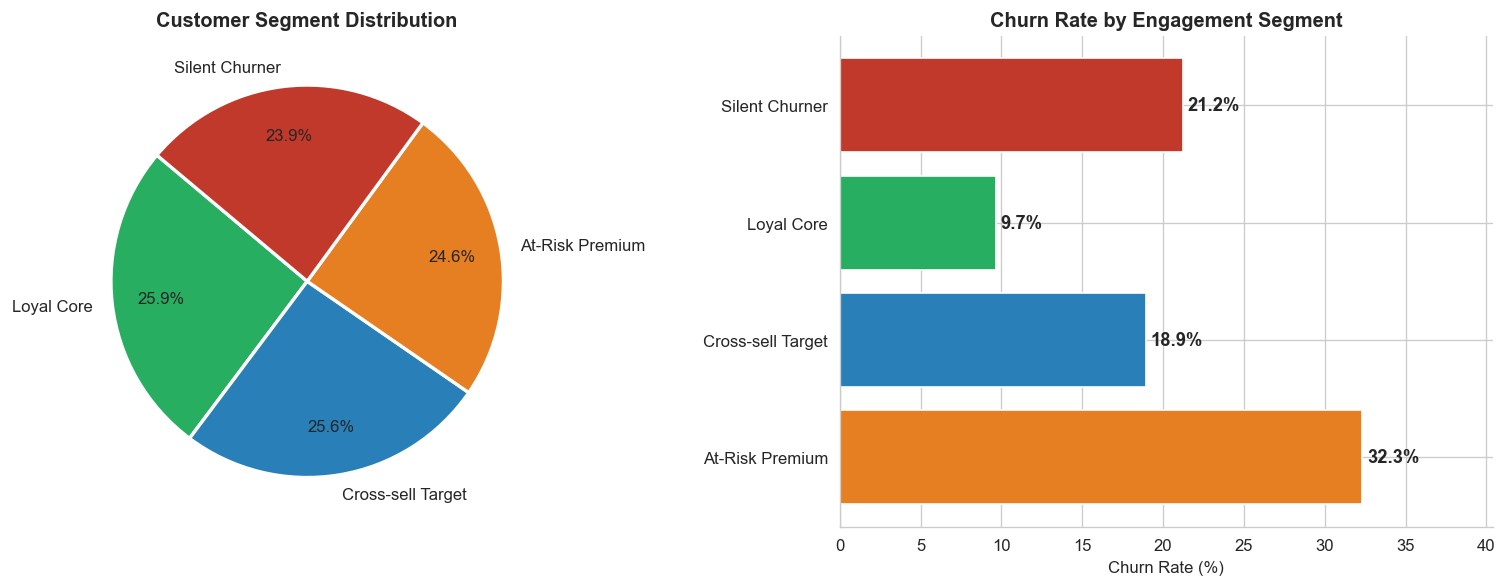

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#segment distribution pie
seg_counts = df['Segment'].value_counts()
axes[0].pie(seg_counts.values,
            labels=seg_counts.index,
            colors=[seg_colors[s] for s in seg_counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2},
            pctdistance=0.75)
axes[0].set_title('Customer Segment Distribution', fontsize=12, fontweight='bold')

#churn rate per segment
seg_churn = df.groupby('Segment')['Exited'].mean() * 100
bars2 = axes[1].barh(seg_churn.index, seg_churn.values,
                     color=[seg_colors[s] for s in seg_churn.index], edgecolor='white')
for bar, val in zip(bars2, seg_churn.values):
    axes[1].text(val+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Engagement Segment', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].set_xlim(0, seg_churn.max() * 1.25)

plt.tight_layout()
plt.savefig('../VISUALS/chart_segments.png', bbox_inches='tight', dpi=150)
plt.show()

#At-Risk Premium segment has the highest churn (32.3%) despite holding high balances
#Loyal Core has the lowest churn (9.7%) - these are the sticky customers

## 12. KPI 2 — Product Depth Index (PDI)

PDI = Retention rate of customers with 2 products

Checks whether having more products means customers stay longer.

In [91]:
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
PDI = (1 - prod_churn.get(2, 0)/100) * 100

print('Churn Rate by Number of Products:')
for prod, rate in prod_churn.items():
    print(f'  {prod} product(s): {rate:.1f}%')
print(f'\nProduct Depth Index (PDI): {PDI:.1f}%')

Churn Rate by Number of Products:
  1 product(s): 27.7%
  2 product(s): 7.6%
  3 product(s): 82.7%
  4 product(s): 100.0%

Product Depth Index (PDI): 92.4%


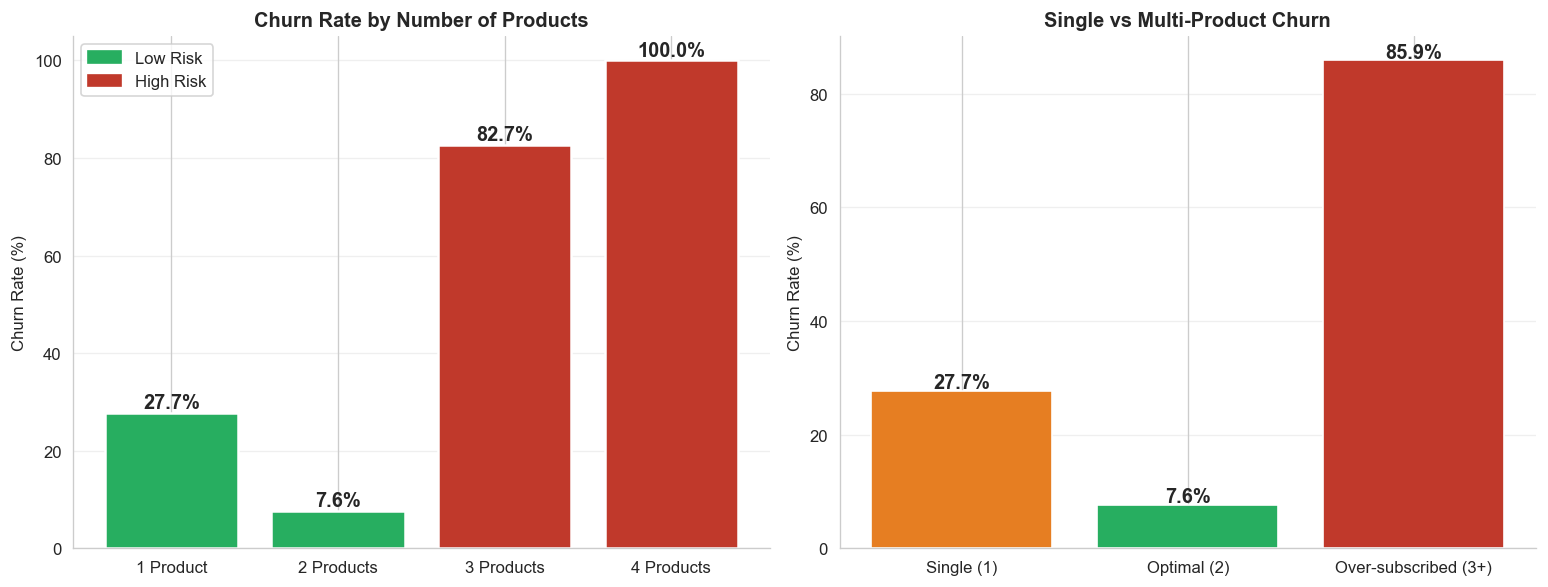

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#churn by product count
p_colors = ['#27ae60' if x <= 2 else '#c0392b' for x in prod_churn.index]
bars_p = axes[0].bar(
    [f'{p} Product{"s" if p>1 else ""}' for p in prod_churn.index],
    prod_churn.values, color=p_colors, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars_p, prod_churn.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Number of Products', fontsize=12, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, alpha=0.3)
green_p = mpatches.Patch(color='#27ae60', label='Low Risk')
red_p   = mpatches.Patch(color='#c0392b', label='High Risk')
axes[0].legend(handles=[green_p, red_p])

#single vs optimal vs over-subscribed — renamed to Product_Depth_Group to avoid overwriting Section 7
df['Product_Depth_Group'] = df['NumOfProducts'].apply(
    lambda x: 'Single (1)' if x==1 else ('Optimal (2)' if x==2 else 'Over-subscribed (3+)'))
pg_churn = df.groupby('Product_Depth_Group')['Exited'].mean() * 100
pg_order = ['Single (1)', 'Optimal (2)', 'Over-subscribed (3+)']
bars_pg = axes[1].bar(pg_order,
                      [pg_churn.get(k,0) for k in pg_order],
                      color=['#e67e22','#27ae60','#c0392b'], edgecolor='white')
for bar, k in zip(bars_pg, pg_order):
    val = pg_churn.get(k, 0)
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Single vs Multi-Product Churn', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../VISUALS/chart_kpi2_product_depth.png', bbox_inches='tight', dpi=150)  # renamed — was overwriting Sec 7
plt.show()

#2 products is the sweet spot - churn drops from 27.7% to 7.6%
#3+ products shows very high churn which is unusual - could be forced cross-selling


## 13. KPI 3 — High-Balance Disengagement Rate (HBDR)

HBDR = Churn rate among inactive customers with above-median balance

Identifies "silent churners" — customers who look financially committed but are not engaged.

In [93]:
hi_bal_inactive = df[(df['Balance'] > med_bal) & (df['IsActiveMember']==0)]
HBDR = hi_bal_inactive['Exited'].mean() * 100

print(f'High-Balance Disengagement Rate (HBDR): {HBDR:.2f}%')
print(f'Total inactive high-balance customers: {len(hi_bal_inactive)}')

High-Balance Disengagement Rate (HBDR): 32.33%
Total inactive high-balance customers: 2456


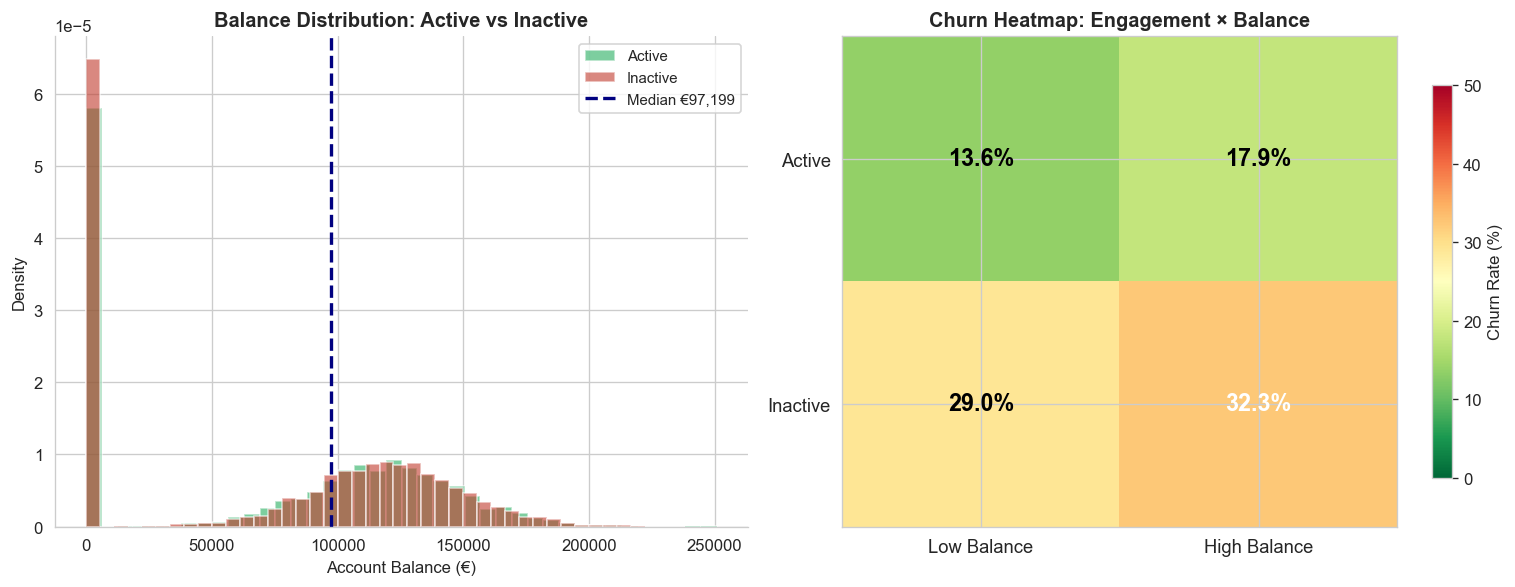

In [94]:
# Active_Label and Bal_Group already created in Section 5
# Re-computing cross table for HBDR heatmap visualization

fig, axes = plt.subplots(1, 2, figsize=(13,5))

#balance distribution by activity
axes[0].hist(df[df['IsActiveMember']==1]['Balance'], bins=40,
             alpha=0.6, color='#27ae60', label='Active', density=True)
axes[0].hist(df[df['IsActiveMember']==0]['Balance'], bins=40,
             alpha=0.6, color='#c0392b', label='Inactive', density=True)
axes[0].axvline(med_bal, color='navy', linestyle='--', linewidth=2,
                label=f'Median €{med_bal:,.0f}')
axes[0].set_xlabel('Account Balance (€)')
axes[0].set_ylabel('Density')
axes[0].set_title('Balance Distribution: Active vs Inactive', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

#heatmap: engagement x balance
cross = df.groupby(['Active_Label','Bal_Group'], observed=True)['Exited'].mean() * 100
heat = cross.unstack()
im = axes[1].imshow(heat.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=50)
axes[1].set_xticks(range(len(heat.columns)))
axes[1].set_xticklabels(heat.columns, fontsize=11)
axes[1].set_yticks(range(len(heat.index)))
axes[1].set_yticklabels(heat.index, fontsize=11)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i,j]
        axes[1].text(j, i, f'{val:.1f}%', ha='center', va='center',
                     fontsize=14, fontweight='bold',
                     color='white' if val > 30 else 'black')
plt.colorbar(im, ax=axes[1], label='Churn Rate (%)', shrink=0.8)
axes[1].set_title('Churn Heatmap: Engagement × Balance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../VISUALS/chart_financial_engagement.png', bbox_inches='tight', dpi=150)
plt.show()

#inactive + high balance is the most dangerous combination
#these customers have money but no loyalty - highest priority for re-engagement


## 14. KPI 4 — Credit Card Stickiness Score (CSS)

CSS = Churn rate without CC − Churn rate with CC

Checks whether credit card ownership reduces churn.

In [95]:
cc_churn   = df[df['HasCrCard']==1]['Exited'].mean() * 100
nocc_churn = df[df['HasCrCard']==0]['Exited'].mean() * 100
CSS = nocc_churn - cc_churn

print(f'Churn with Credit Card:    {cc_churn:.2f}%')
print(f'Churn without Credit Card: {nocc_churn:.2f}%')
print(f'Credit Card Stickiness Score (CSS): {CSS:.2f} percentage points')

Churn with Credit Card:    20.18%
Churn without Credit Card: 20.81%
Credit Card Stickiness Score (CSS): 0.63 percentage points


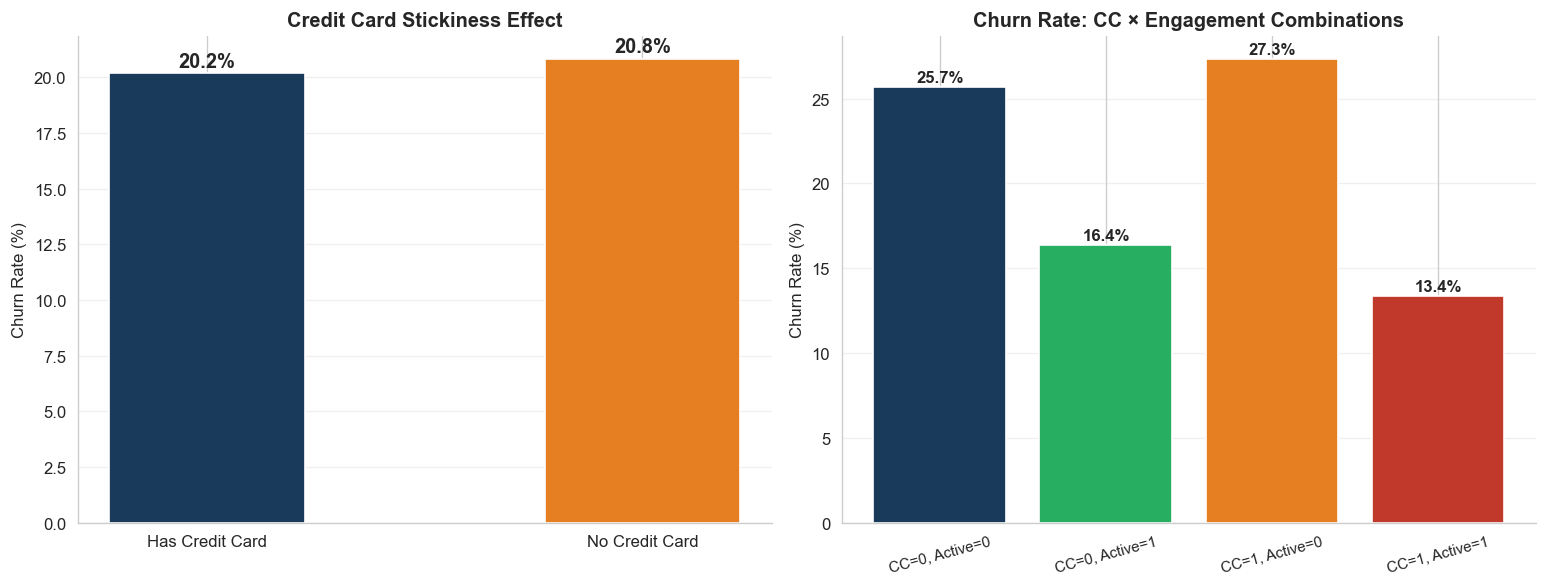

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

bars_cc = axes[0].bar(['Has Credit Card','No Credit Card'],
                      [cc_churn, nocc_churn],
                      color=['#1a3a5c','#e67e22'], width=0.45, edgecolor='white')
for bar, val in zip(bars_cc, [cc_churn, nocc_churn]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Credit Card Stickiness Effect', fontsize=12, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, alpha=0.3)

#combination of credit card + active status
combo = df.groupby(['HasCrCard','IsActiveMember'])['Exited'].mean() * 100
combo_df = combo.reset_index()
combo_df['Label'] = combo_df.apply(
    lambda r: f'CC={int(r["HasCrCard"])}, Active={int(r["IsActiveMember"])}', axis=1)
bars_cm = axes[1].bar(combo_df['Label'], combo_df['Exited'],
                      color=['#1a3a5c','#27ae60','#e67e22','#c0392b'], edgecolor='white')
for bar, val in zip(bars_cm, combo_df['Exited']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate: CC × Engagement Combinations', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)
plt.xticks(rotation=15, fontsize=9)

plt.tight_layout()
plt.savefig('../VISUALS/chart_creditcard_stickiness.png', bbox_inches='tight', dpi=150)
plt.show()

#credit card alone doesn't make a big difference (~0.6pp)
#but credit card + active together shows the lowest churn - combination matters

## 15. KPI 5 — Relationship Strength Index (RSI)

RSI combines 5 signals into a single 0–100 score per customer:
- IsActiveMember → 30 pts
- NumOfProducts (max 3) → 30 pts
- HasCrCard → 10 pts
- Tenure (normalized) → 20 pts
- High Balance → 10 pts

In [97]:
avg_rsi_retained = df[df['Exited']==0]['RSI'].mean()
avg_rsi_churned  = df[df['Exited']==1]['RSI'].mean()

print(f'Avg RSI - Retained: {avg_rsi_retained:.2f}')
print(f'Avg RSI - Churned:  {avg_rsi_churned:.2f}')
print(f'RSI Gap: {avg_rsi_retained - avg_rsi_churned:.2f} points')

Avg RSI - Retained: 53.93
Avg RSI - Churned:  48.27
RSI Gap: 5.66 points


In [98]:
df['RSI_Tier'] = pd.cut(df['RSI'], bins=[0,30,50,70,100],
                         labels=['Very Low (0-30)','Low (31-50)','Medium (51-70)','High (71-100)'])

rsi_churn = df.groupby('RSI_Tier', observed=True)['Exited'].agg(['mean','count'])
rsi_churn['mean'] *= 100
print(rsi_churn.round(2))

                  mean  count
RSI_Tier                     
Very Low (0-30)  31.06   1172
Low (31-50)      24.13   3589
Medium (51-70)   15.75   3404
High (71-100)    14.77   1835


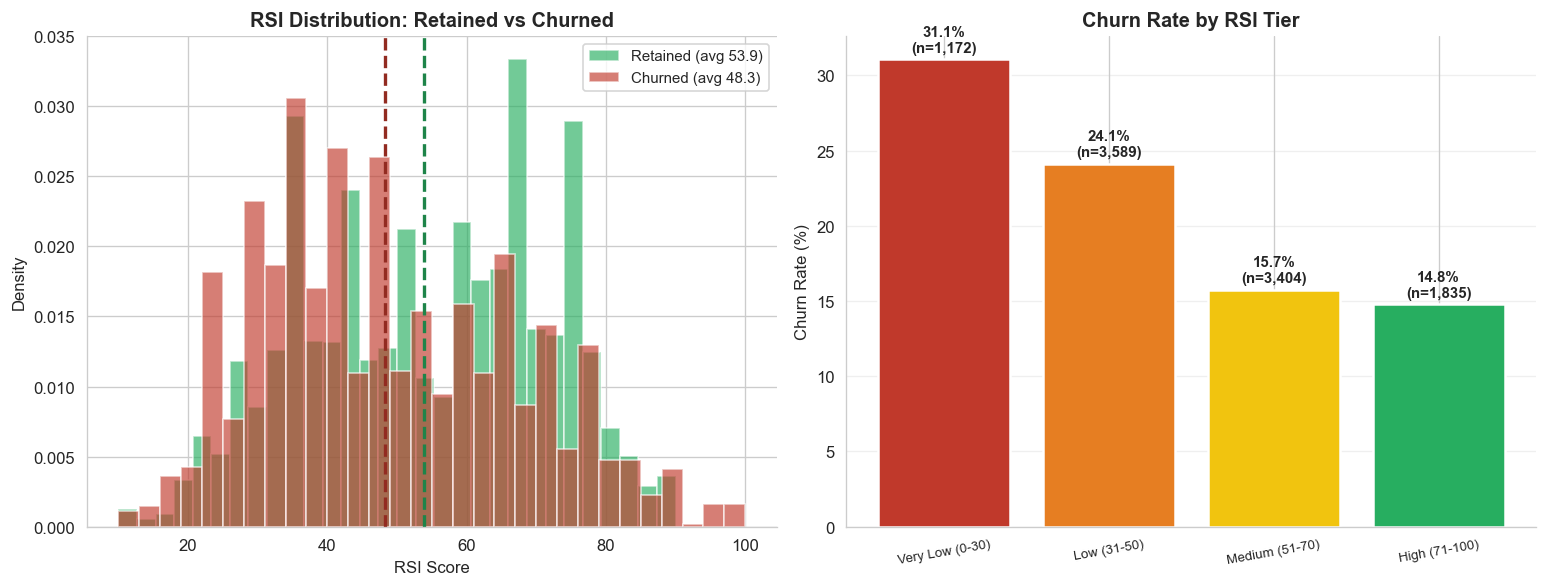

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#RSI distribution: retained vs churned
axes[0].hist(df[df['Exited']==0]['RSI'], bins=30, alpha=0.65,
             color='#27ae60', label=f'Retained (avg {avg_rsi_retained:.1f})', density=True)
axes[0].hist(df[df['Exited']==1]['RSI'], bins=30, alpha=0.65,
             color='#c0392b', label=f'Churned (avg {avg_rsi_churned:.1f})', density=True)
axes[0].axvline(avg_rsi_retained, color='#1e8449', linestyle='--', linewidth=2)
axes[0].axvline(avg_rsi_churned,  color='#922b21', linestyle='--', linewidth=2)
axes[0].set_xlabel('RSI Score')
axes[0].set_ylabel('Density')
axes[0].set_title('RSI Distribution: Retained vs Churned', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

#churn rate by RSI tier
tier_colors = ['#c0392b','#e67e22','#f1c40f','#27ae60']
bars_rsi = axes[1].bar(rsi_churn.index.astype(str), rsi_churn['mean'],
                       color=tier_colors, edgecolor='white', linewidth=1.5)
for bar, row in zip(bars_rsi, rsi_churn.itertuples()):
    label = str(round(row.mean, 1)) + '%' + '\n' + '(n=' + f'{row.count:,}' + ')'
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 label, ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by RSI Tier', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.grid(True, alpha=0.3)
plt.xticks(fontsize=8, rotation=10)

plt.tight_layout()
plt.savefig('../VISUALS/chart_rsi_scoring.png', bbox_inches='tight', dpi=150)
plt.show()

#clear pattern - higher RSI = lower churn
#RSI can be used as an early warning score to flag customers at risk

## 16. Correlation Analysis

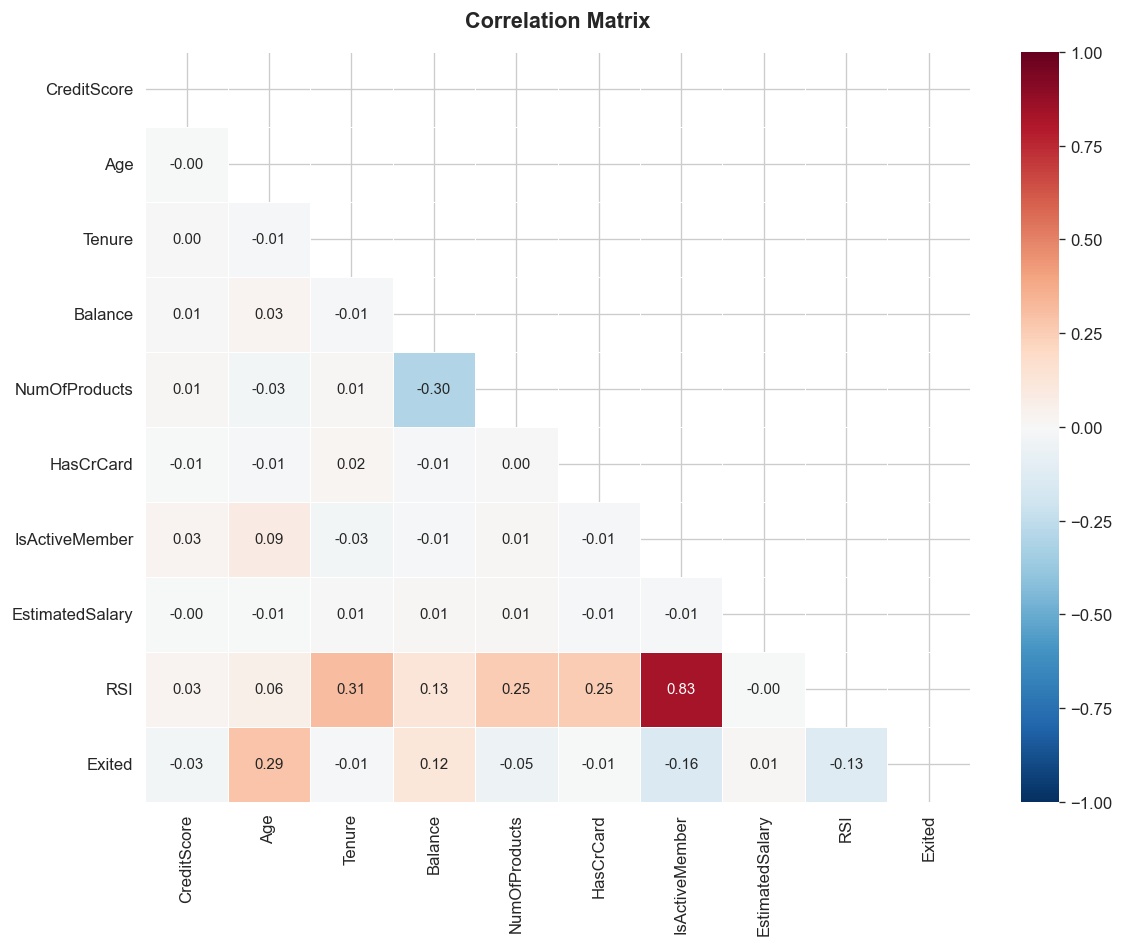

In [100]:
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'HasCrCard','IsActiveMember','EstimatedSalary','RSI','Exited']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':9}, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../VISUALS/chart_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

In [101]:
#top features correlated with churn
churn_corr = corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print('Correlation with Churn (Exited):')
for col, val in churn_corr.items():
    direction = 'increases churn' if val > 0 else 'reduces churn'
    print(f'  {col:20s}: {val:+.3f}  → {direction}')

Correlation with Churn (Exited):
  Age                 : +0.285  → increases churn
  IsActiveMember      : -0.156  → reduces churn
  RSI                 : -0.128  → reduces churn
  Balance             : +0.119  → increases churn
  NumOfProducts       : -0.048  → reduces churn
  CreditScore         : -0.027  → reduces churn
  Tenure              : -0.014  → reduces churn
  EstimatedSalary     : +0.012  → increases churn
  HasCrCard           : -0.007  → reduces churn


## 17. KPI Summary

Final summary of all 5 KPIs calculated in this analysis.

In [102]:
#computing all KPIs
ERR  = (df[df['IsActiveMember']==0]['Exited'].mean() /
        df[df['IsActiveMember']==1]['Exited'].mean())
PDI  = (1 - df.groupby('NumOfProducts')['Exited'].mean().get(2, 0)) * 100
HBDR = df[(df['Balance']>med_bal)&(df['IsActiveMember']==0)]['Exited'].mean()*100
CSS  = (df[df['HasCrCard']==0]['Exited'].mean() - df[df['HasCrCard']==1]['Exited'].mean())*100
RSI_avg = df['RSI'].mean()

kpi_summary = pd.DataFrame({
    'KPI': [
        'Engagement Retention Ratio (ERR)',
        'Product Depth Index (PDI)',
        'High-Balance Disengagement Rate (HBDR)',
        'Credit Card Stickiness Score (CSS)',
        'Avg Relationship Strength Index (RSI)'
    ],
    'Value': [
        f'{ERR:.2f}x',
        f'{PDI:.1f}%',
        f'{HBDR:.1f}%',
        f'{CSS:.2f}pp',
        f'{RSI_avg:.1f}/100'
    ]
})
kpi_summary

,KPI,Value
0,Engagement Retention Ratio (ERR),1.88x
1,Product Depth Index (PDI),92.4%
2,High-Balance Disengagement Rate (HBDR),32.3%
3,Credit Card Stickiness Score (CSS),0.63pp
4,Avg Relationship Strength Index (RSI),52.8/100


## 18. Conclusion & Recommendations

**Key findings:**
- Inactive members churn at almost 2x the rate of active members (ERR = 1.88x)
- 2-product customers have the lowest churn (7.6%) — bundling is the most effective retention tool
- Inactive high-balance customers are the biggest silent churn risk (HBDR = 32.3%)
- Germany consistently shows higher churn than France and Spain
- RSI effectively separates retained vs churned customers — can be used as an early warning score

**Recommendations:**
- Push 2-product bundles aggressively for single-product customers
- Re-engage inactive high-balance customers through personalized outreach before they leave
- Investigate Germany-specific factors driving higher churn
- Use RSI < 30 as an early warning flag for at-risk customers
- Loyalty programs should target Loyal Core segment to maintain the low 9.7% churn rate

## 19. Machine Learning — Churn Prediction (Random Forest)

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

#prepare features
df_ml = df.copy()
le_geo = LabelEncoder()  # separate encoder for each categorical column
le_gen = LabelEncoder()
df_ml['Geography_enc'] = le_geo.fit_transform(df_ml['Geography'])
df_ml['Gender_enc']    = le_gen.fit_transform(df_ml['Gender'])

features = ['CreditScore','Geography_enc','Gender_enc','Age','Tenure',
            'Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','RSI']
X = df_ml[features]
y = df_ml['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)


Train size: (8000, 11)
Test size: (2000, 11)


In [104]:
#train random forest with class_weight='balanced' to improve churn recall
model = RandomForestClassifier(n_estimators=100, random_state=42,
                               n_jobs=-1, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {acc*100:.2f}%')
print('(class_weight=balanced used to improve recall for minority churn class)')


Model Accuracy: 86.75%
(class_weight=balanced used to improve recall for minority churn class)


In [105]:
#detailed classification report
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

              precision    recall  f1-score   support

    Retained       0.88      0.97      0.92      1607
     Churned       0.79      0.45      0.57       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



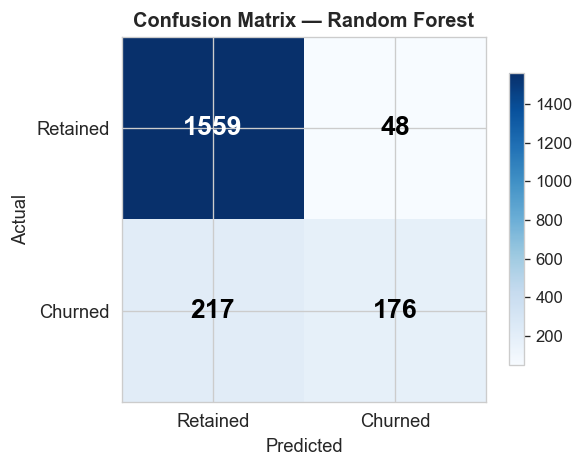

In [106]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['Retained','Churned'], fontsize=11)
ax.set_yticks([0,1]); ax.set_yticklabels(['Retained','Churned'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix — Random Forest', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('../VISUALS/chart_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

#model correctly identifies most retained customers
#recall for churned class shows how many actual churners were caught

In [107]:
#feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importance Ranking:')
print(importance_df.to_string(index=False))

Feature Importance Ranking:
        Feature  Importance
            Age    0.244979
        Balance    0.126031
EstimatedSalary    0.124836
  NumOfProducts    0.124802
    CreditScore    0.119739
            RSI    0.098411
         Tenure    0.063969
  Geography_enc    0.036527
 IsActiveMember    0.023697
     Gender_enc    0.021933
      HasCrCard    0.015076


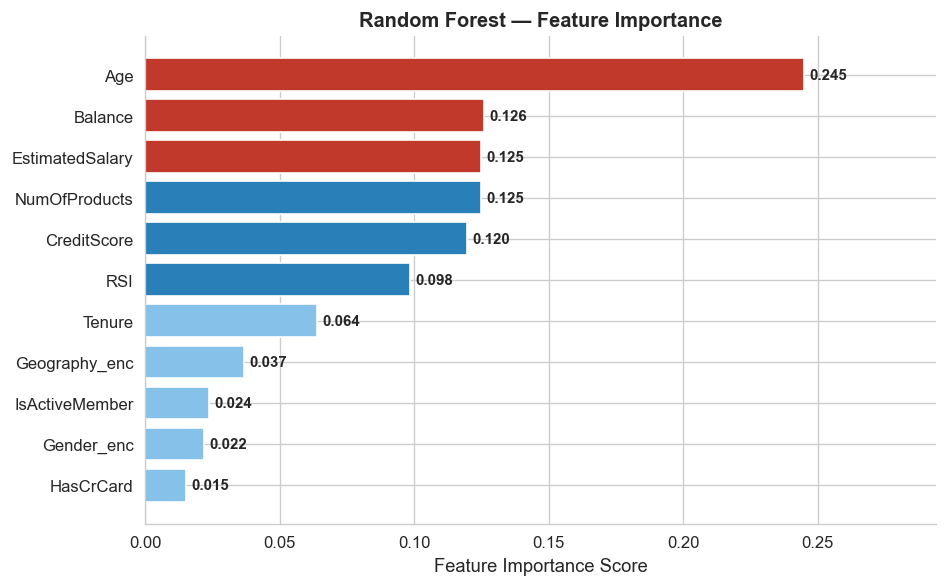

In [108]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c0392b' if i < 3 else '#2980b9' if i < 6 else '#85c1e9'
          for i in range(len(importance_df))]
bars = ax.barh(importance_df['Feature'][::-1],
               importance_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, importance_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('../VISUALS/chart_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

#top features confirm EDA findings - age, balance, RSI and active status are key churn drivers

ML-Predicted Churn Probability by Segment:
  At-Risk Premium          : 32.2%
  Silent Churner           : 20.8%
  Cross-sell Target        : 19.1%
  Loyal Core               : 9.9%


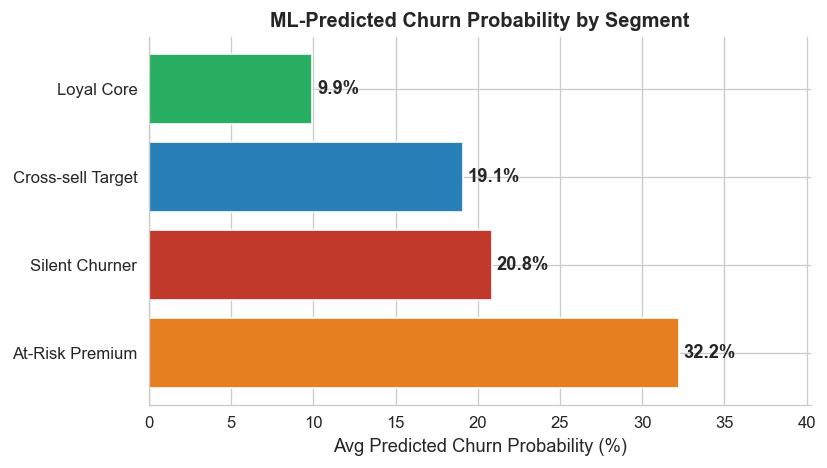

In [109]:
#churn probability by segment
probs = model.predict_proba(X)[:, 1]
df_ml['Churn_Probability'] = probs

seg_prob = df_ml.groupby('Segment')['Churn_Probability'].mean() * 100
seg_prob = seg_prob.sort_values(ascending=False)

print('ML-Predicted Churn Probability by Segment:')
for seg, prob in seg_prob.items():
    print(f'  {seg:25s}: {prob:.1f}%')

seg_colors_ml = {
    'At-Risk Premium':   '#e67e22',
    'Silent Churner':    '#c0392b',
    'Cross-sell Target': '#2980b9',
    'Loyal Core':        '#27ae60'
}

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [seg_colors_ml.get(s, '#888') for s in seg_prob.index]
bars = ax.barh(seg_prob.index, seg_prob.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, seg_prob.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Avg Predicted Churn Probability (%)', fontsize=11)
ax.set_title('ML-Predicted Churn Probability by Segment', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, seg_prob.max() * 1.25)
plt.tight_layout()
plt.savefig('../VISUALS/chart_ml_segment_probability.png', bbox_inches='tight', dpi=150)
plt.show()

#ML predictions align closely with EDA findings - validates the analytical approach

In [110]:
#ML KPI summary
report_dict = classification_report(y_test, y_pred, output_dict=True)

print('=' * 50)
print('  ML MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Algorithm:  Random Forest (100 trees)')
print(f'  Accuracy:   {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  Precision:  {report_dict["1"]["precision"]*100:.2f}%')
print(f'  Recall:     {report_dict["1"]["recall"]*100:.2f}%')
print(f'  F1 Score:   {report_dict["1"]["f1-score"]*100:.2f}%')
print('=' * 50)
print(f'  Top churn driver: {importance_df.iloc[0]["Feature"]}')
print(f'  Importance score: {importance_df.iloc[0]["Importance"]:.3f}')
print('=' * 50)

  ML MODEL PERFORMANCE SUMMARY
  Algorithm:  Random Forest (100 trees)
  Accuracy:   86.75%
  Precision:  78.57%
  Recall:     44.78%
  F1 Score:   57.05%
  Top churn driver: Age
  Importance score: 0.245


In [111]:
#saving cleaned dataset with all new features
df.to_csv('european_bank_cleaned.csv', index=False)
print('Saved: european_bank_cleaned.csv')
print('Shape:', df.shape)
print('New columns added:', ['Segment', 'RSI', 'RSI_Tier', 'Bal_Group', 'Active_Label', 'Product_Group'])

Saved: european_bank_cleaned.csv
Shape: (10000, 23)
New columns added: ['Segment', 'RSI', 'RSI_Tier', 'Bal_Group', 'Active_Label', 'Product_Group']
